# Data Processing of Balaji Fast Food Sales



In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Balaji Fast Food Sales.csv")
df


,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening
...,...,...,...,...,...,...,...,...,...,...
995,996,3/19/2023,Frankie,Fastfood,50,10,500,NaN,Mrs.,Evening
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,NaN,Mr.,Evening
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,NaN,Mr.,Evening
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,NaN,Mrs.,Afternoon


In [3]:
df.shape

(1000, 10)

In [4]:
df.isnull().sum()


order_id                0
date                    0
item_name               0
item_type               0
item_price              0
quantity                0
transaction_amount      0
transaction_type      107
received_by             0
time_of_sale            0
dtype: int64

In [5]:
df["transaction_type"]=df["transaction_type"].fillna("unknown")


In [6]:
df.isnull().sum()

order_id              0
date                  0
item_name             0
item_type             0
item_price            0
quantity              0
transaction_amount    0
transaction_type      0
received_by           0
time_of_sale          0
dtype: int64

In [7]:
df.describe()


,order_id,item_price,quantity,transaction_amount
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,33.315000,8.162000,275.230000
std,288.819436,14.921744,4.413075,204.402979
min,1.000000,20.000000,1.000000,20.000000
25%,250.750000,20.000000,4.000000,120.000000
50%,500.500000,25.000000,8.000000,240.000000
75%,750.250000,50.000000,12.000000,360.000000
max,1000.000000,60.000000,15.000000,900.000000


In [8]:
df.duplicated().value_counts()

False    1000
Name: count, dtype: int64

In [9]:
dg=df.loc[df['received_by']=="Mrs."]
dg

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
8,9,06-10-2022,Panipuri,Fastfood,20,1,20,Cash,Mrs.,Morning
10,11,12-01-2022,Frankie,Fastfood,50,8,400,Online,Mrs.,Afternoon
11,12,07-12-2022,Vadapav,Fastfood,20,8,160,Online,Mrs.,Night
12,13,12/22/2022,Panipuri,Fastfood,20,9,180,Online,Mrs.,Afternoon
14,15,02-03-2023,Aalopuri,Fastfood,20,3,60,Cash,Mrs.,Evening
...,...,...,...,...,...,...,...,...,...,...
992,993,7/17/2022,Frankie,Fastfood,50,3,150,Online,Mrs.,Night
993,994,11-01-2022,Panipuri,Fastfood,20,2,40,Online,Mrs.,Evening
995,996,3/19/2023,Frankie,Fastfood,50,10,500,unknown,Mrs.,Evening
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,unknown,Mrs.,Afternoon


In [10]:
df[df["time_of_sale"]=="Midnight"].value_counts().sum()

199

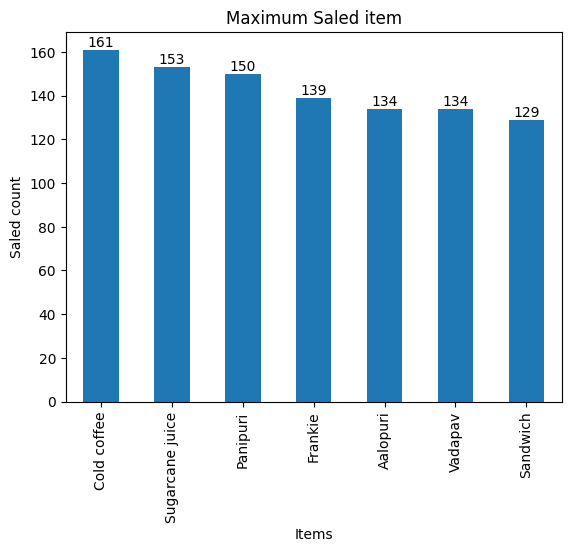

In [11]:
(df["item_name"].value_counts()).plot(kind="bar")
plt.title("Maximum Saled item")
plt.xlabel("Items")
plt.ylabel("Saled count")
for index,value in enumerate(df["item_name"].value_counts()):
    plt.text(index ,value+0,str(value) ,ha='center' ,va='bottom')
plt.show()

In [12]:
df["date"]=pd.to_datetime(df["date"],format='mixed')
df["month"]=df["date"].dt.month_name()
df


,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale,month
0,1,2022-07-03,Aalopuri,Fastfood,20,13,260,unknown,Mr.,Night,July
1,2,2022-08-23,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon,August
2,3,2022-11-20,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon,November
3,4,2023-02-03,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night,February
4,5,2022-10-02,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening,October
...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-03-19,Frankie,Fastfood,50,10,500,unknown,Mrs.,Evening,March
996,997,2022-09-20,Sandwich,Fastfood,60,7,420,unknown,Mr.,Evening,September
997,998,2023-01-26,Sandwich,Fastfood,60,13,780,unknown,Mr.,Evening,January
998,999,2022-08-27,Panipuri,Fastfood,20,5,100,unknown,Mrs.,Afternoon,August


In [13]:
ds=pd.DataFrame(df.groupby("month")["transaction_amount"].sum())
ds

,transaction_amount
month,
April,17670
August,22305
December,23460
February,25595
January,28670
July,19490
June,17335
March,25390
May,26570


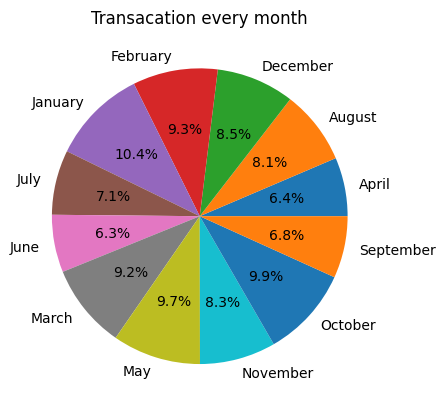

In [14]:
plt.pie(x=ds['transaction_amount'],labels=ds.index,autopct='%1.1f%%')
plt.title('Transacation every month')
plt.show()


In [40]:
s=df['item_type'].value_counts()     
s

item_type
Fastfood     686
Beverages    314
Name: count, dtype: int64

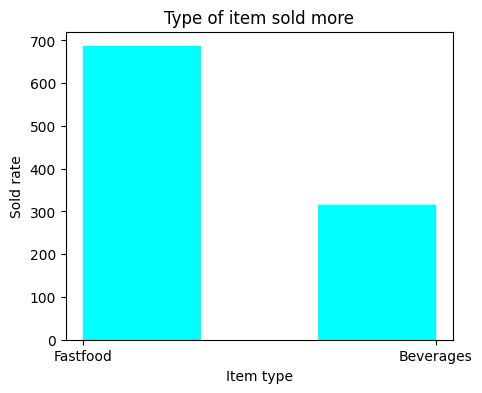

In [50]:
plt.figure(figsize=(5,4))
plt.hist(df['item_type'], bins=3,color='aqua')
plt.title("Type of item sold more")
plt.xlabel("Item type")
plt.ylabel("Sold rate")
plt.show()

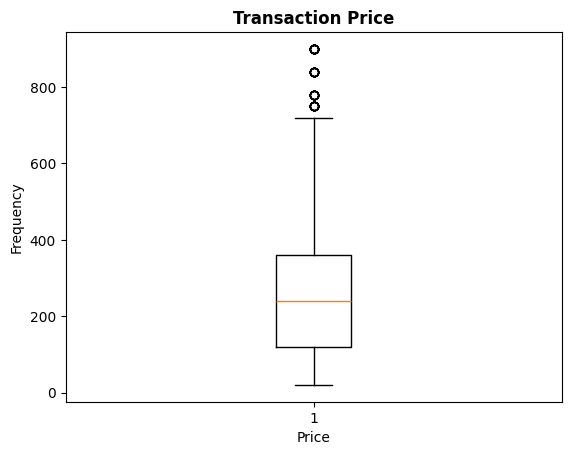

In [48]:
plt.boxplot(df['transaction_amount'])
plt.title('Transaction Price',fontweight='bold')
plt.xlabel('Price')
plt.ylabel('Frequency')
#plt.grid(True)
plt.show()

In [54]:
a=df.groupby('received_by')['time_of_sale'].value_counts()

received_by  time_of_sale
Mr.          Afternoon       113
             Night           109
             Evening         105
             Morning         100
             Midnight         85
Mrs.         Midnight        114
             Evening          96
             Night            96
             Afternoon        92
             Morning          90
Name: count, dtype: int64

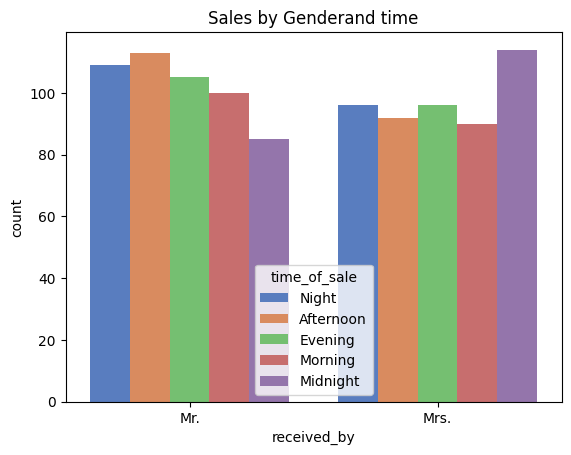

In [60]:
sns.countplot(x='received_by',hue='time_of_sale',data=df,palette='muted')
plt.title("Sales by Genderand time")
plt.show()

## Conclusion 


According to the data of 1000 people of Balaji Fast Food Sales conclude that,
    
    > The cold coffee has sold more in the Balaji Fast food.
    > In the month of January has more trancation amount.
    > In this shop fastfood has more sale than the beverages.
    > In this shop Mrs. were ordered more in the midnight.
